# Roll Perturbation $\Delta\phi$

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import sympy
from sympy import Derivative, Matrix, Symbol, cos, sin

f = Symbol("f")
xc = Symbol("x_c")
yc = Symbol("y_c")

# Original camera pose
phi = Symbol("phi")  # Roll
theta = Symbol("theta")  # Pitch
psi = Symbol("psi")  # Yaw
x = Symbol("x")
y = Symbol("y")
# Non-zero otherwise degenerate homography since camera center aligned with plane
z = Symbol("z", nonzero=True)

# Viewpoint delta
dphi = Symbol("\Delta\phi")  # Roll
dtheta = Symbol("\Delta\\theta")  # Pitch
dpsi = Symbol("\Delta\psi")  # Yaw
dx = Symbol("\Delta x")
dy = Symbol("\Delta y")
dz = Symbol("\Delta z")

## Define homography matrix

In [24]:
H_inv = Matrix(
    [
        [cos(dphi), -sin(dphi), -xc * cos(dphi) + xc + yc * sin(dphi)],
        [sin(dphi), cos(dphi), -xc * sin(dphi) - yc * cos(dphi) + yc],
        [0, 0, 1],
    ]
)
H_inv

Matrix([
[cos(\Delta\phi), -sin(\Delta\phi), -x_c*cos(\Delta\phi) + x_c + y_c*sin(\Delta\phi)],
[sin(\Delta\phi),  cos(\Delta\phi), -x_c*sin(\Delta\phi) - y_c*cos(\Delta\phi) + y_c],
[              0,                0,                                                1]])

## Apply projective transform

In [25]:
u = Symbol("u")
v = Symbol("v")

p0 = H_inv @ Matrix([u, v, 1])
p0 = p0 / p0[2]  # Normalize for non-homogeneous coordinates
p0 = sympy.simplify(p0)

u0 = p0[0]
v0 = p0[1]

In [26]:
u0

u*cos(\Delta\phi) - v*sin(\Delta\phi) - x_c*cos(\Delta\phi) + x_c + y_c*sin(\Delta\phi)

In [27]:
v0

u*sin(\Delta\phi) + v*cos(\Delta\phi) - x_c*sin(\Delta\phi) - y_c*cos(\Delta\phi) + y_c

## Compute gradient

In [28]:
du0_dK = Derivative(u0, dphi, evaluate=True).simplify()
du0_dK

-u*sin(\Delta\phi) - v*cos(\Delta\phi) + x_c*sin(\Delta\phi) + y_c*cos(\Delta\phi)

In [29]:
dv0_dK = Derivative(v0, dphi, evaluate=True).simplify()
dv0_dK

u*cos(\Delta\phi) - v*sin(\Delta\phi) - x_c*cos(\Delta\phi) + y_c*sin(\Delta\phi)

## Compute gradient derivative

In [30]:
Derivative(du0_dK, dphi, evaluate=True).simplify()

-u*cos(\Delta\phi) + v*sin(\Delta\phi) + x_c*cos(\Delta\phi) - y_c*sin(\Delta\phi)

In [31]:
Derivative(dv0_dK, dphi, evaluate=True).simplify()

-u*sin(\Delta\phi) - v*cos(\Delta\phi) + x_c*sin(\Delta\phi) + y_c*cos(\Delta\phi)

## Plots

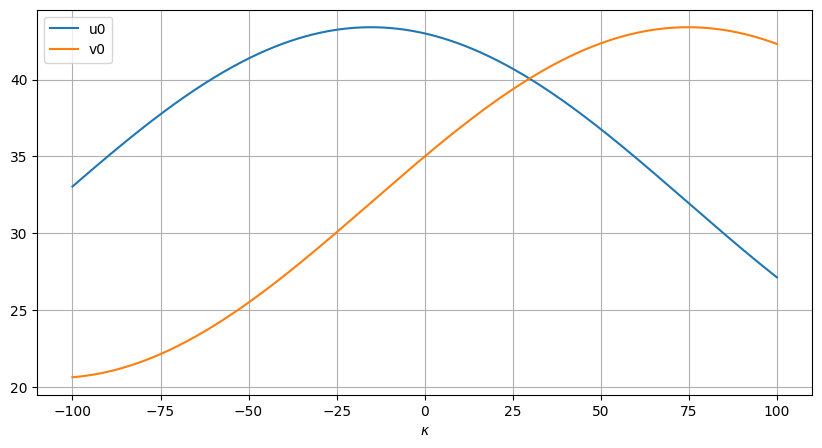

In [32]:
k_values = np.deg2rad(np.linspace(-100, 100, 1000))

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})

u0_values = [u0_subs.subs({dphi: val}).evalf() for val in k_values]
v0_values = [v0_subs.subs({dphi: val}).evalf() for val in k_values]

u0_values = np.array(u0_values, dtype=float)
v0_values = np.array(v0_values, dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(np.rad2deg(k_values), u0_values, label="u0")
plt.plot(np.rad2deg(k_values), v0_values, label="v0")
plt.xlabel(r"$\kappa$")
plt.legend()
plt.grid(True)
plt.show()